# Часть 0. Структура папок

Создали следуюую структуру папок:

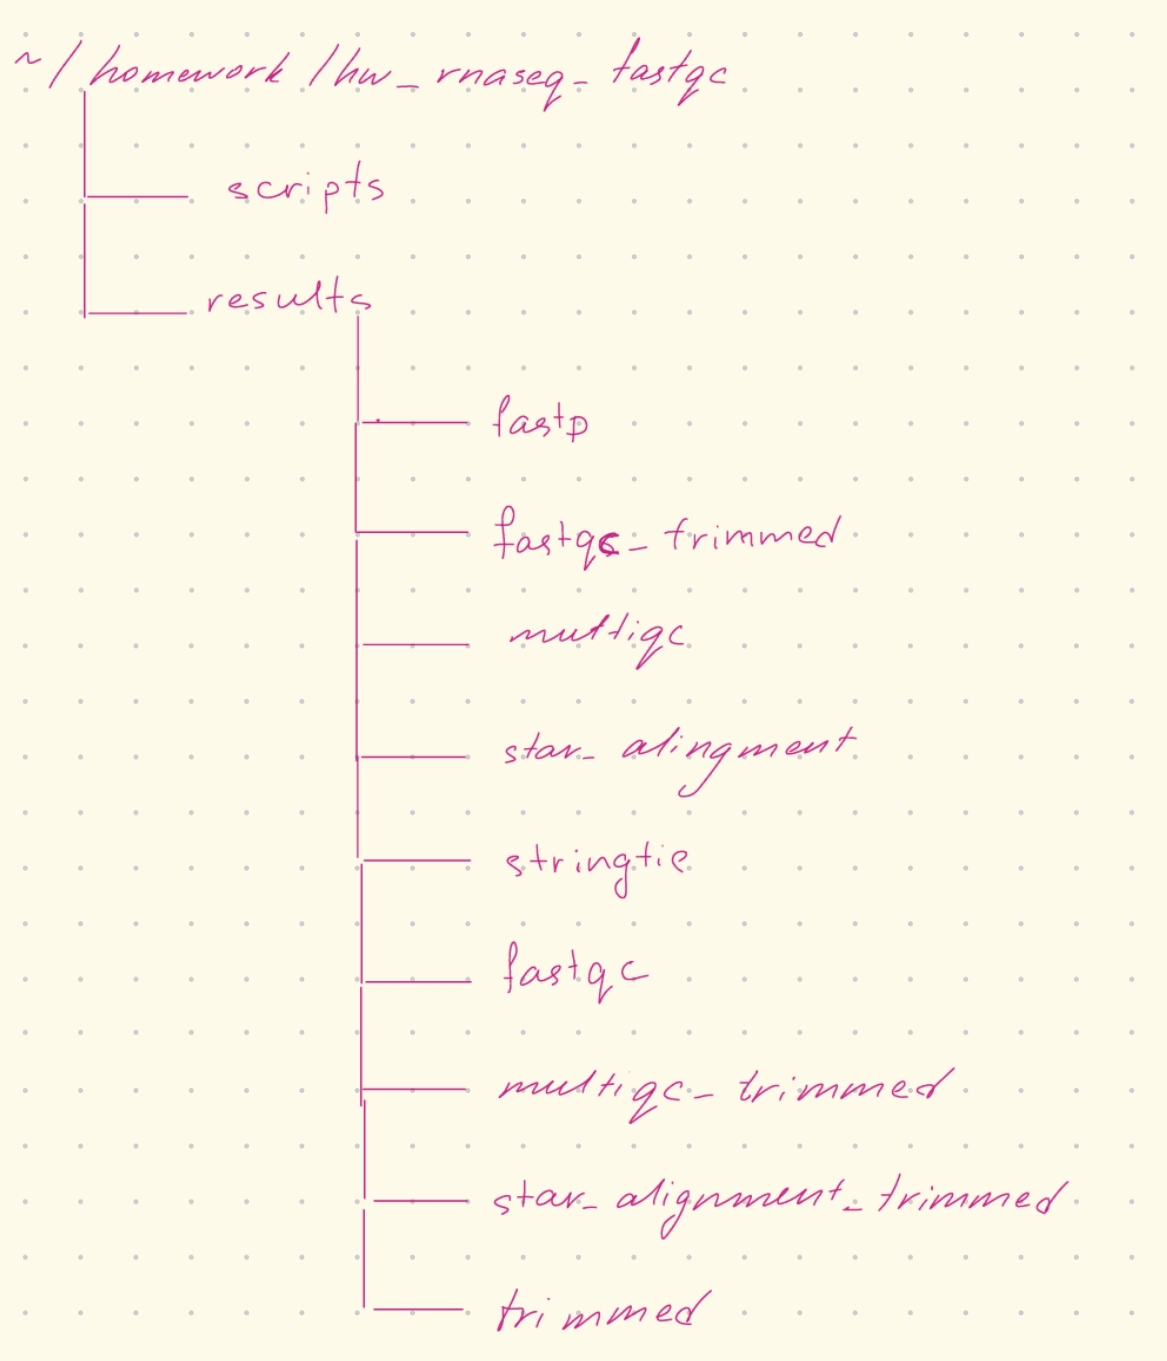

# Часть 1. Анализ FastQC

Из условий задания нам известно расположение данных
```
/home/STUDY/FBMF/bioinformatics/rnaseq_map_star/raw_data/Eg_Treg_S71_R1_001.fastq.gz
/home/STUDY/FBMF/bioinformatics/rnaseq_map_star/raw_data/Eg_Treg_S71_R2_001.fastq.gz
```



Создали скрипт run_fastqc_multiqc.slurm, этот скрипт запускает FastQC для двух сырых FASTQ-файлов, чтобы оценить качество секвенирования, а затем собирает все полученные отчеты в единый сводный отчет с помощью MultiQC. Используем наше окружение из предыдущего дз, в котором есть fastqc и multiqc.

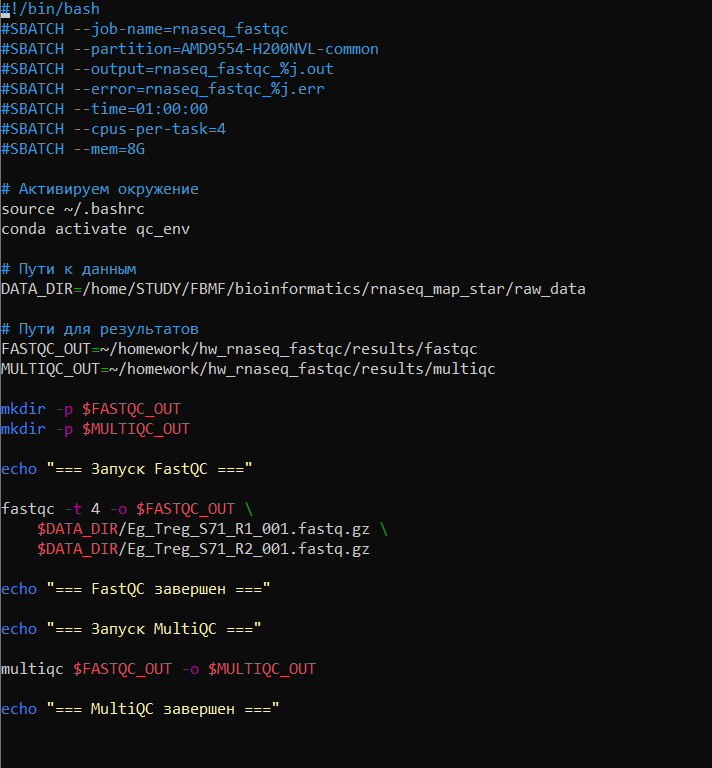

Полученный отчет multiqc_report был загружен на локальный компьютер как multiqc_report_hw6.html

# Часть 2. Тримминг

Из полученного отчета видим, что в наших данных присутствуют адаптеры, причем виден рост до приблизительно 1.5% на последних 20 bp.


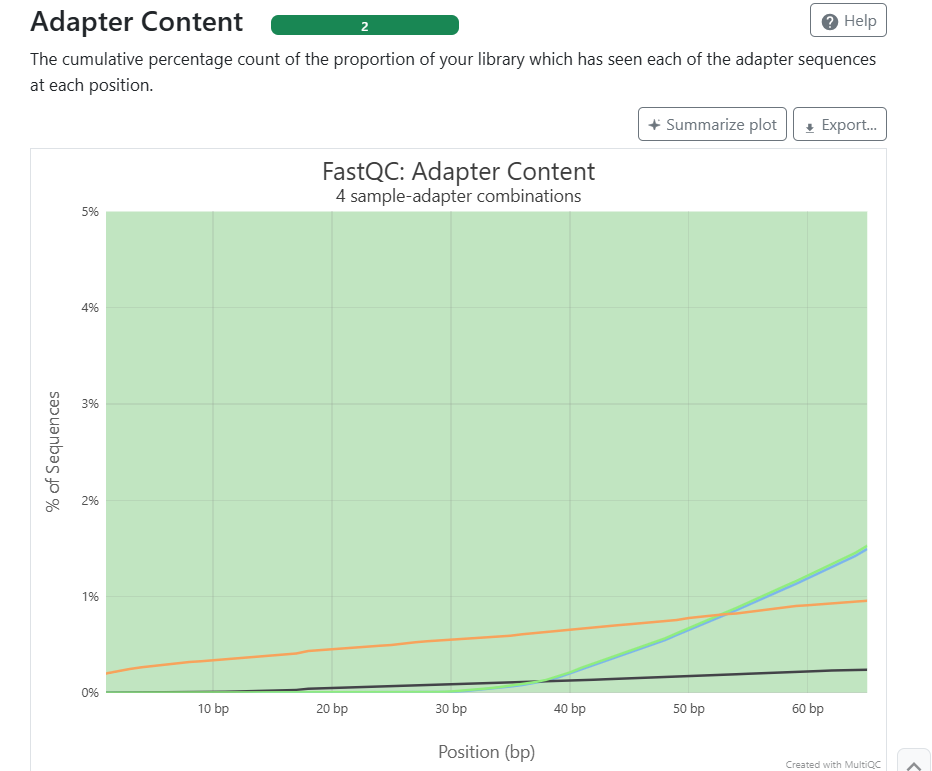

Участки с плохим качеством в конце ридов отсутствуют, однако снижение качества на концах ридов (Q $≈$ 33–35) заметно.

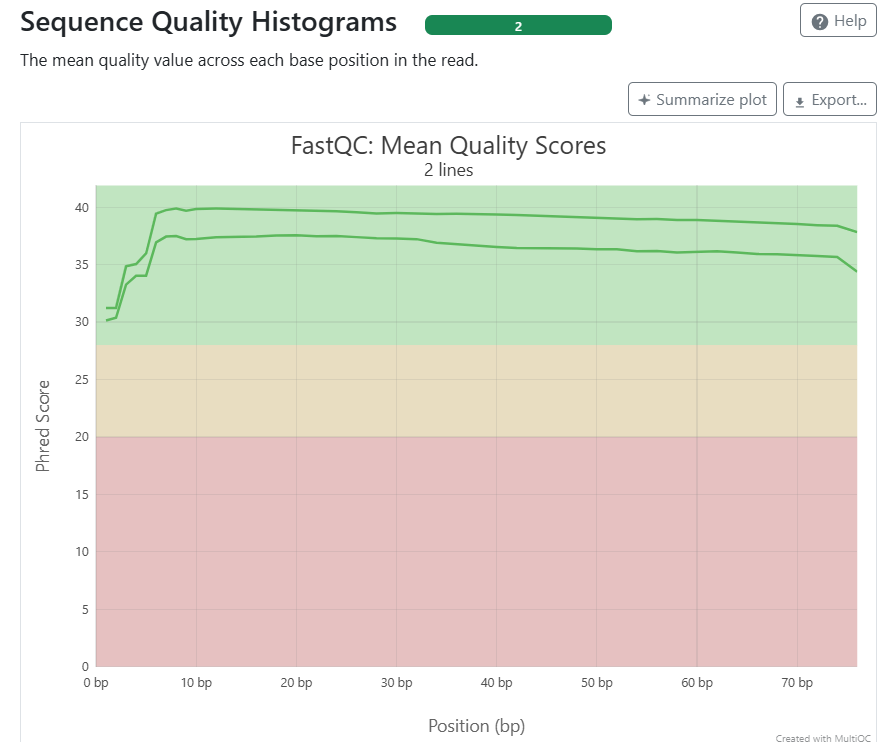

Итого, мы можем выделить следующие проблемные аспекты до тримминга:
- Наличие адаптеров
- Снижение качества на концах ридов

А также:
- Ненормальное распределение GC-состава

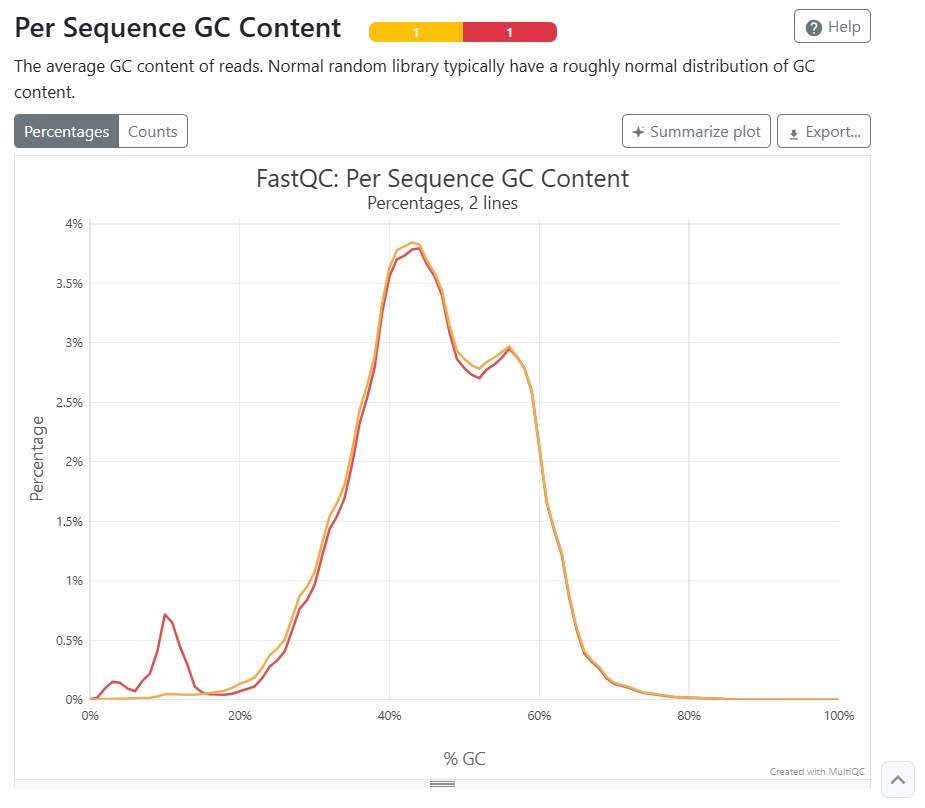

Сделали тримминг. Для тримминга использовалась программа fastp с автоматическим определением адаптеров (--detect_adapter_for_pe), поскольку в был обнаружен адаптерный контент на уровне ~1.5%.

Для удаления низкокачественных участков применялось скользящее окно размером 5 нуклеотидов с порогом средней оценки качества Q20 (--cut_window_size 5, --cut_mean_quality 20). Это связано с тем, что в исходных данных наблюдалось умеренное снижение качества на последних 10-15 нуклеотидах ридов.

Минимальная длина рида после тримминга была установлена на уровне 36 п.н. (--length_required 36), что обеспечивает корректное выравнивание RNA-seq ридов и исключает слишком короткие фрагменты, которые обычно не выравниваются уникально.

Таким образом, выбранные параметры позволяют удалить адаптерные следы, улучшить качество концов ридов и сохранить достаточную длину для корректного выравнивания.

Все это реализовано в скрипте run_fastp.slurm соответственно.



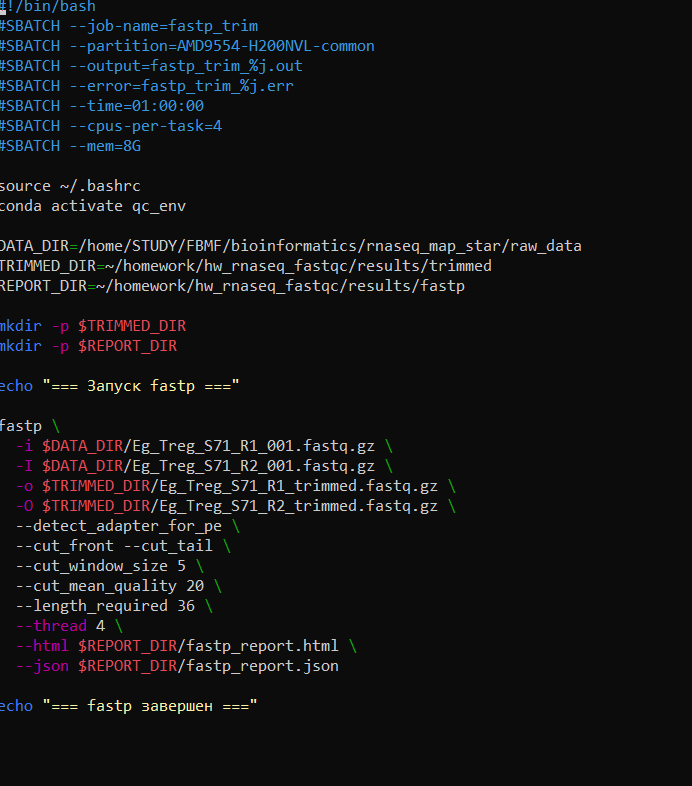

Вновь выполнили анализ FastQC и объединили результаты с помощью MultiQC.
Реализовано в скрипте run_fastqc_multiqc_trimmed.slurm

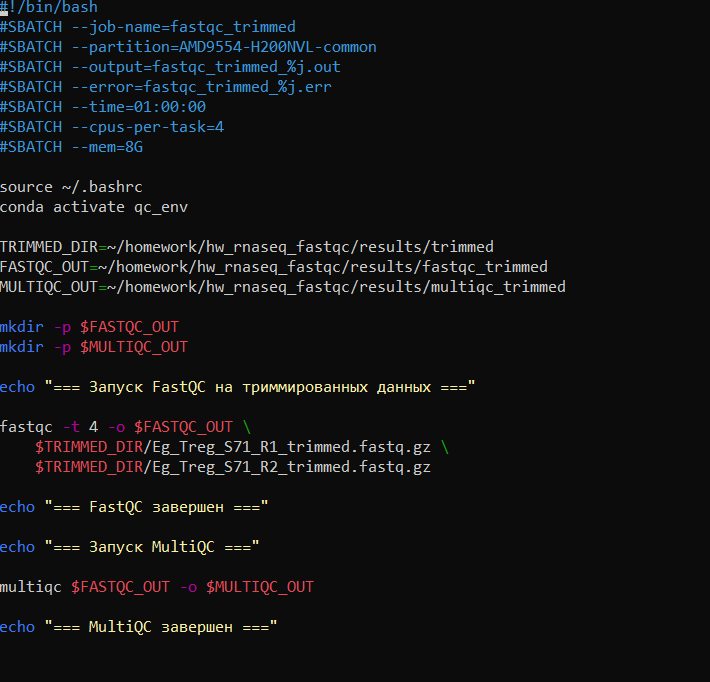

Полученный отчет вновь сохранили на локальный коспьютер для просмотра как multiqc_report_hw_6_trimmed.html


После тримминга в данных остается небольшая доля адаптерных последовательностей (0.62% и 0.24%), их уровень ниже исходного и не является критичным для выравнивания.

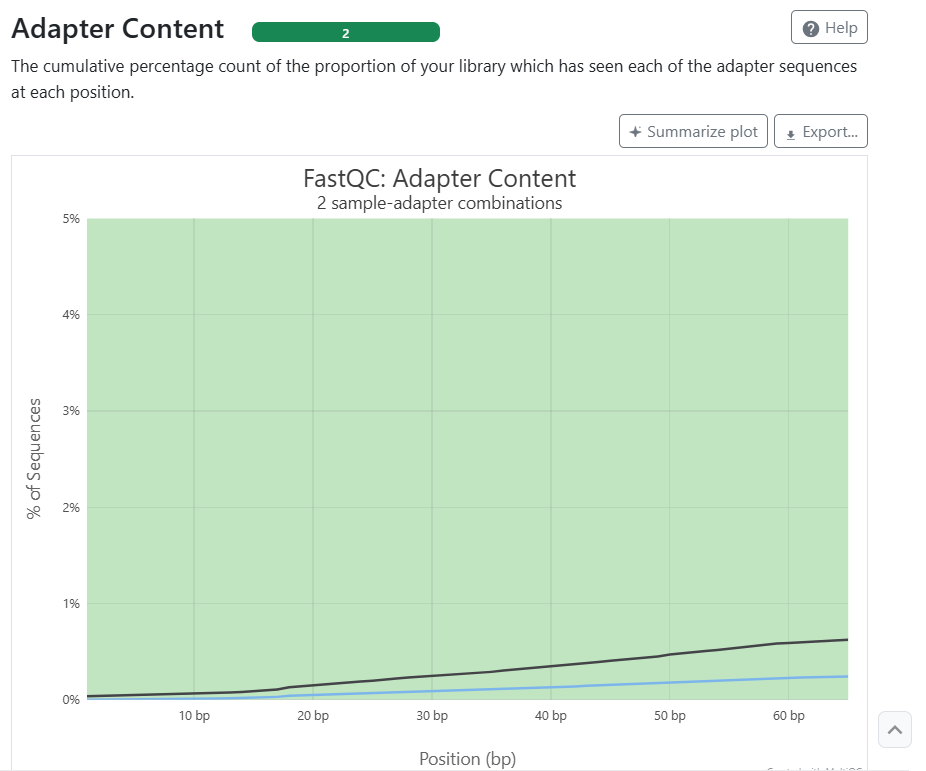

Концы ридов стали "чище", графики стали ровнее, стабильное Q $\approx$ 37–40 по всей длине, падение в конце до более высоких значений.

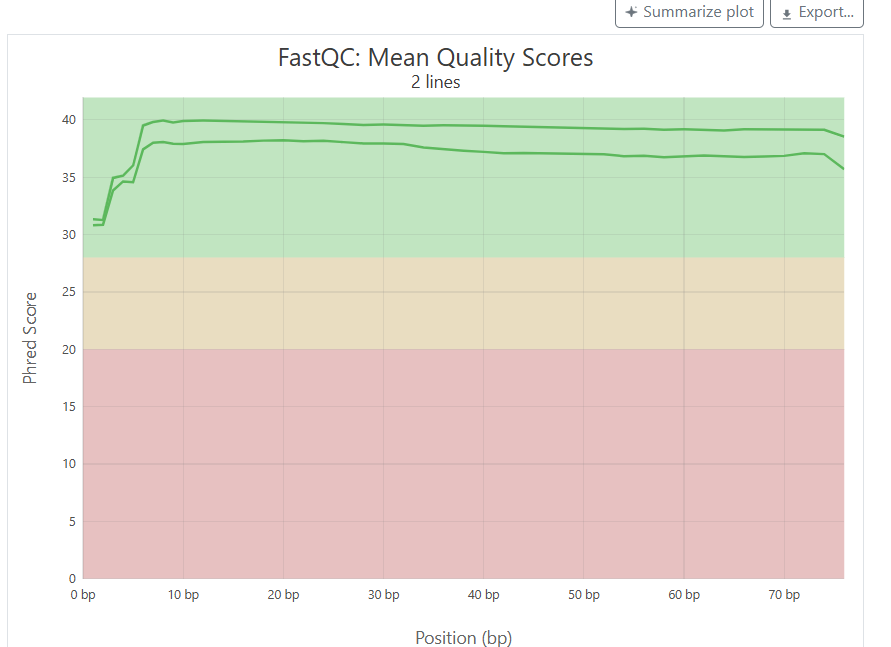

Распределние GC-состава стало ближе к нормальному, одна из кривых из "красной" перешла в "желтую", однако так как тримминг лишь убирает адаптеры и низкокачественные хвосты, но не меняет фундаментально состав транскриптов, общий вид распределения (двугорбость) сохраняется.

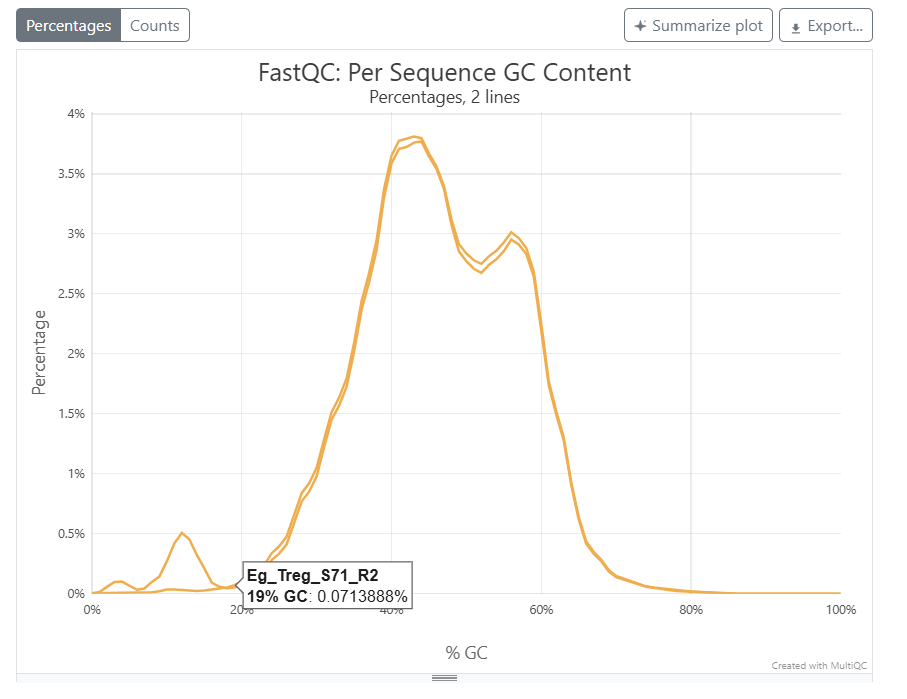

Заметим также, что распределение длины ридов стало менее однородным по сравнению с исходными данными, что связано с обрезкой низкокачественных участков и адаптерных хвостов.

Стало:
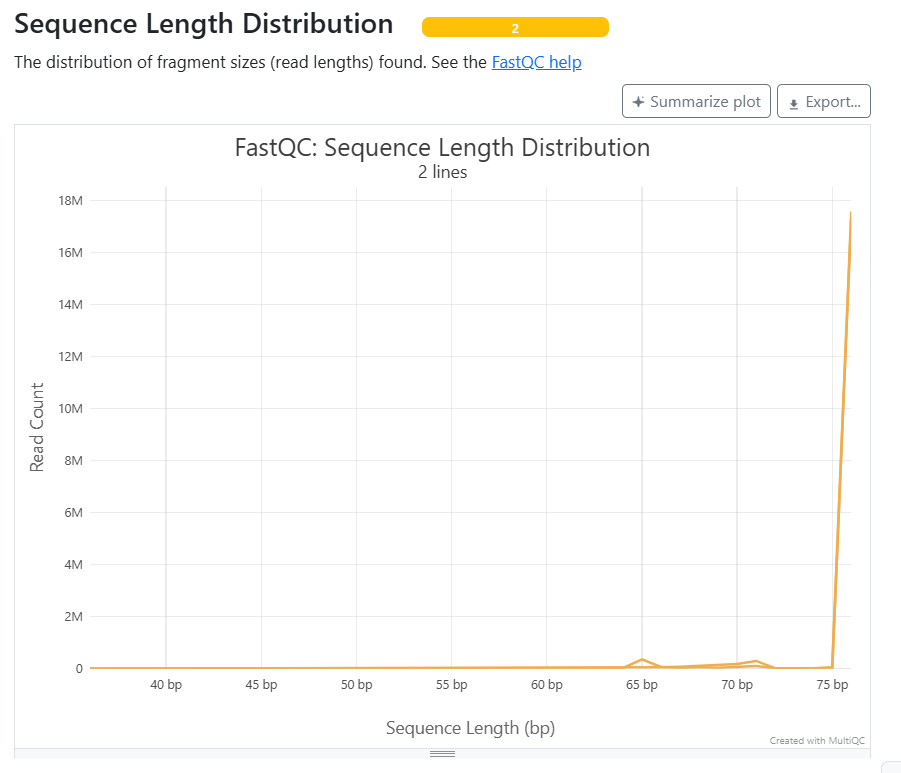

Было:
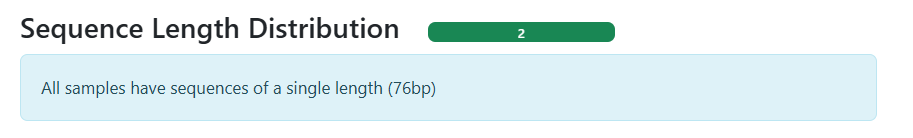

Для дальнейшего выравнивания будем использовать триммированные данные, так как именно триммированные риды скорее всего обеспечат более высокую точность выравнивания, так как они почти не содержат адаптерных последовательностей и низкокачественных участков, что снизит количество ложных совпадений и повысит точность оценки экспрессии генов.

# Часть 3. Выравнивание на референсный геном — STAR + StringTie

Референсный геном лежит по пути:
```
/home/STUDY/FBMF/bioinformatics/GRCh38/
```



Cоздали дополнительное окружение:
```
conda create -n rnaseq_env python=3.10
```
В которое установили необходимые для сборки инструменты:
```
conda activate rnaseq_env
conda install -c bioconda star stringtie htseq
```




Написали скрипт run_star.slurm, который делает выравнивание триммированных ридов на референсный геном с помощью STAR.

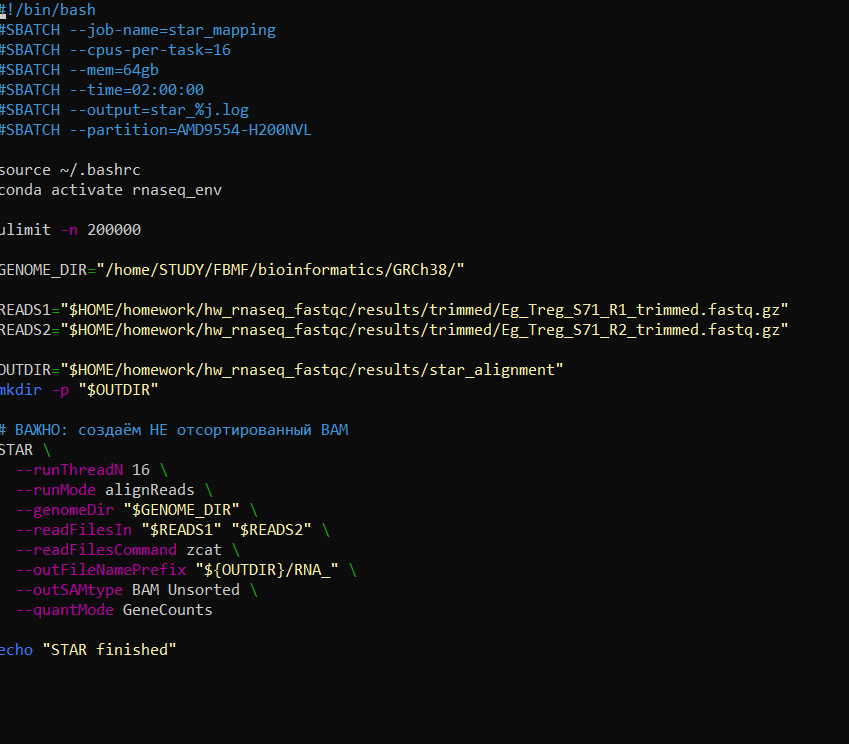

Также написали скрипт run_stringtie.slurm, который запускает StringTie на отсортированном BAM‑файле, полученном после выравнивания STAR, и выполняет сборку транскриптов de novo с оценкой их экспрессии. Он создаёт файл transcripts.gtf, содержащий структуру всех собранных транскриптов, их экзонов и количественные метрики (coverage, FPKM, TPM).

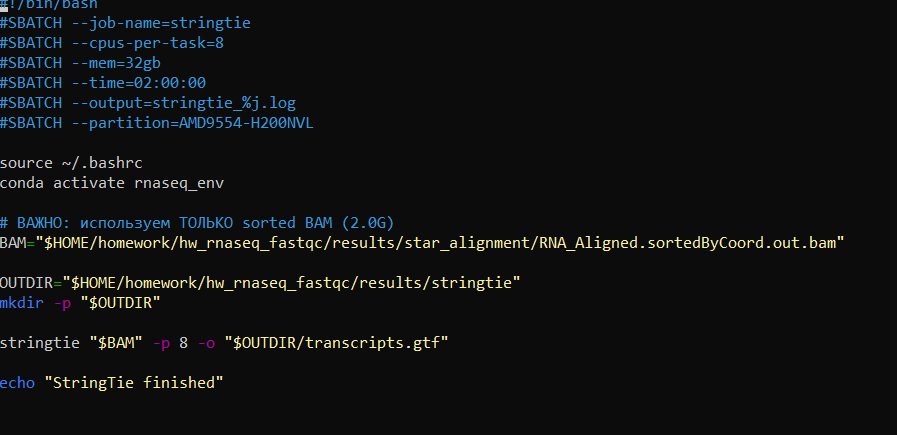

Посмотрим первые 10 строк
```
head -n 10 ~/homework/hw_rnaseq_fastqc/results/stringtie/transcripts.gtf
```



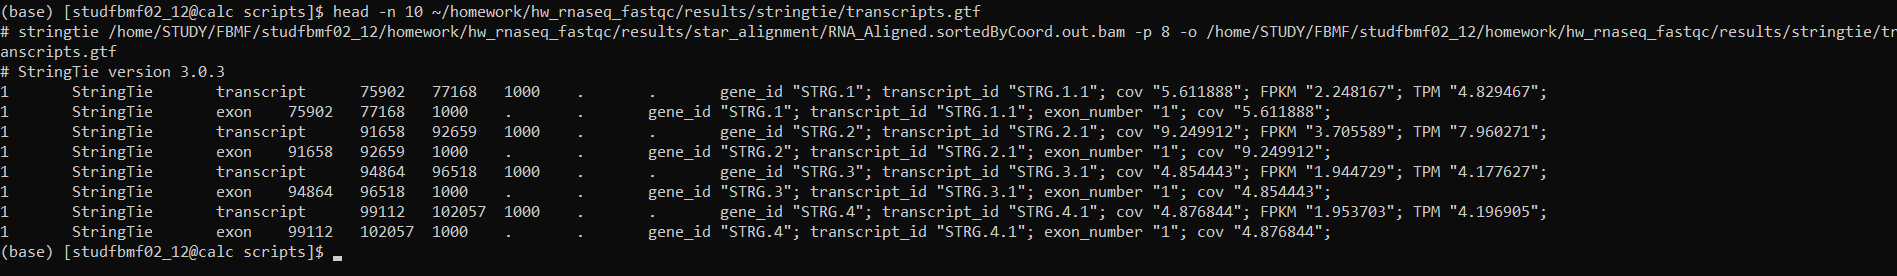

Кратко опишем полученный GTF-файл:


---


Поле: chrom

Пример значения: 1

Описание: Номер хромосомы, на которой расположен транскрипт



---

Поле: source

Приемер значения: StringTie

Описание: Программа, создавшая аннотацию


---

Поле: type

Приемер значения: transcript/exon

Описание: Тип элемента: транскрипт или экзон



---
Поле: start

Приемер значения: 75902

Описание: Начальная координата элемента



---
Поле: end

Приемер значения: 77168

Описание: Конечная координата элемента



---
Поле: score

Приемер значения: 1000

Описание: Оценка качества



---
Поле: strand

Приемер значения: .

Описание: Направление цепи (+, -, или . если не определено)



---
Поле: frame

Приемер значения: .

Описание: Чтение рамки (для CDS, здесь не используется)



---
Поле: attributes

Приемер значения: gene_id, transcript_id, exon_number, cov, FPKM, TPM

Описание: Дополнительные параметры: идентификаторы и количественные метрики








Также посмотрим количество транскриптов:
```
 grep -c "transcript" ~/homework/hw_rnaseq_fastqc/results/stringtie/transcripts.gtf
```
StringTie собрал 185779 транскриптов, включая как известные, так и потенциально новые (de novo).



Сборка транскриптов с помощью StringTie позволяет восстановить структуру транскриптов на основе выравненных RNA-seq ридов, определить альтернативные изоформы, оценить их экспрессию (coverage, FPKM, TPM) и обнаружить новые транскрипты, отсутствующие в референсной аннотации.


Файл transcripts.gtf содержит полную аннотацию собранных транскриптов и экзонов и используется для анализа структуры транскриптов, альтернативного сплайсинга, объединения аннотаций между образцами и последующего анализа экспрессии на уровне транскриптов.

Вставим также скриншот, полученного выравнивания:

```
ls -lh /home/STUDY/FBMF/studfbmf02_12/homework/hw_rnaseq_fastqc/results/star_alignment

```



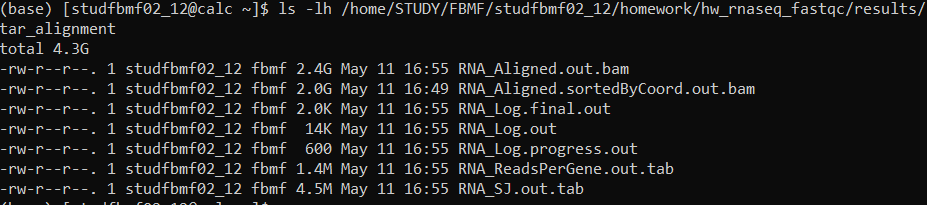

# Часть 4. Выравнивание на референсный геном

Выровняли риды на референсный геном
```
/home/STUDY/FBMF/bioinformatics/GRCh38/
```
с помощью HTSeq, написав скрипт nano run_htseq.slurm, апускает HTSeq-count, который читает отсортированный BAM-файл STAR и аннотацию генома в формате GTF, после чего подсчитывает количество ридов, пересекающих экзоны каждого гена. Он работает в режиме --stranded no, использует позиционный порядок BAM и записывает итоговую таблицу каунтов в файл htseq_counts.txt.

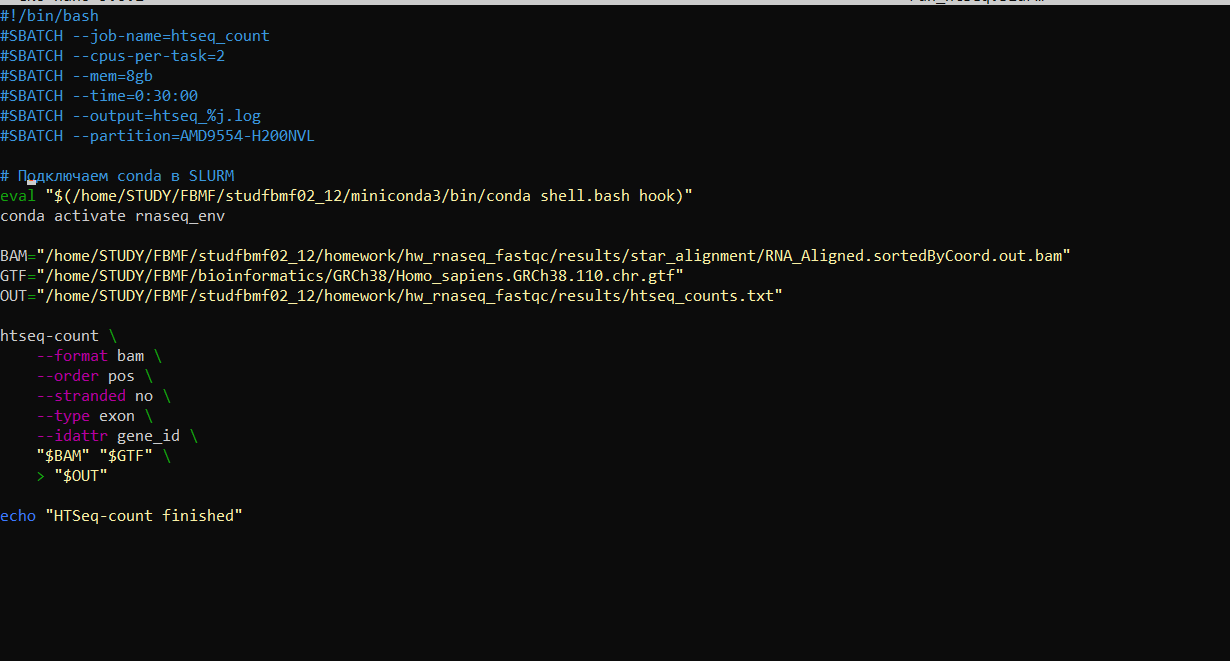

Найдем количество уникальных генов получили в htseq_counts.txt:
```
grep -v "^__" /home/STUDY/FBMF/studfbmf02_12/homework/hw_rnaseq_fastqc/results/htseq_counts.txt | wc -l
```
Количество уникальных генов: 62700



Сравниv каунты из STAR (RNA_ReadsPerGene.out.tab, колонка 3) с HTSeq-countб для этого построим scatter plot при помощи python (compare_star_htseq.py)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Пути к файлам
star_path = "/home/STUDY/FBMF/studfbmf02_12/homework/hw_rnaseq_fastqc/results/star_alignment/RNA_ReadsPerGene.out.tab"
htseq_path = "/home/STUDY/FBMF/studfbmf02_12/homework/hw_rnaseq_fastqc/results/htseq_counts.txt"

# Читаем STAR RNA_ReadsPerGene.out.tab
star = pd.read_csv(
    star_path,
    sep="\t",
    header=None,
    comment=None,
    names=["gene_id", "star_unstranded", "star_strand1", "star_strand2"]
)

# Убираем служебные строки, начинающиеся с "__"
star = star[~star["gene_id"].str.startswith("__")].copy()

# Берем колонку 3 = unstranded
star_counts = star[["gene_id", "star_unstranded"]].copy()

# Читаем HTSeq htseq_counts.txt
htseq = pd.read_csv(
    htseq_path,
    sep="\t",
    header=None,
    names=["gene_id", "htseq_count"]
)

# Убираем служебные строки
htseq = htseq[~htseq["gene_id"].str.startswith("__")].copy()

# Мерджим по gene_id
merged = pd.merge(star_counts, htseq, on="gene_id", how="inner")

print(f"Общее число генов после объединения: {merged.shape[0]}")

# Считаем корреляцию
corr_pearson = merged["star_unstranded"].corr(merged["htseq_count"], method="pearson")
corr_spearman = merged["star_unstranded"].corr(merged["htseq_count"], method="spearman")

print(f"Pearson r = {corr_pearson:.4f}")
print(f"Spearman r = {corr_spearman:.4f}")

# Лог-трансформация для красивого scatter
x = merged["star_unstranded"].astype(float)
y = merged["htseq_count"].astype(float)

# log10(count + 1), чтобы не было log(0)
x_log = np.log10(x + 1)
y_log = np.log10(y + 1)

# Рисуем scatter
plt.figure(figsize=(6, 6))
plt.scatter(x_log, y_log, s=5, alpha=0.3)

plt.xlabel("STAR counts (log10, unstranded, column 3)")
plt.ylabel("HTSeq counts (log10)")
plt.title(f"STAR vs HTSeq gene counts\nPearson r = {corr_pearson:.3f}, Spearman r = {corr_spearman:.3f}")

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("star_vs_htseq_scatter.png", dpi=300)
plt.close()

print("Готово. Файл графика: star_vs_htseq_scatter.png")

Получили график следующего вида:

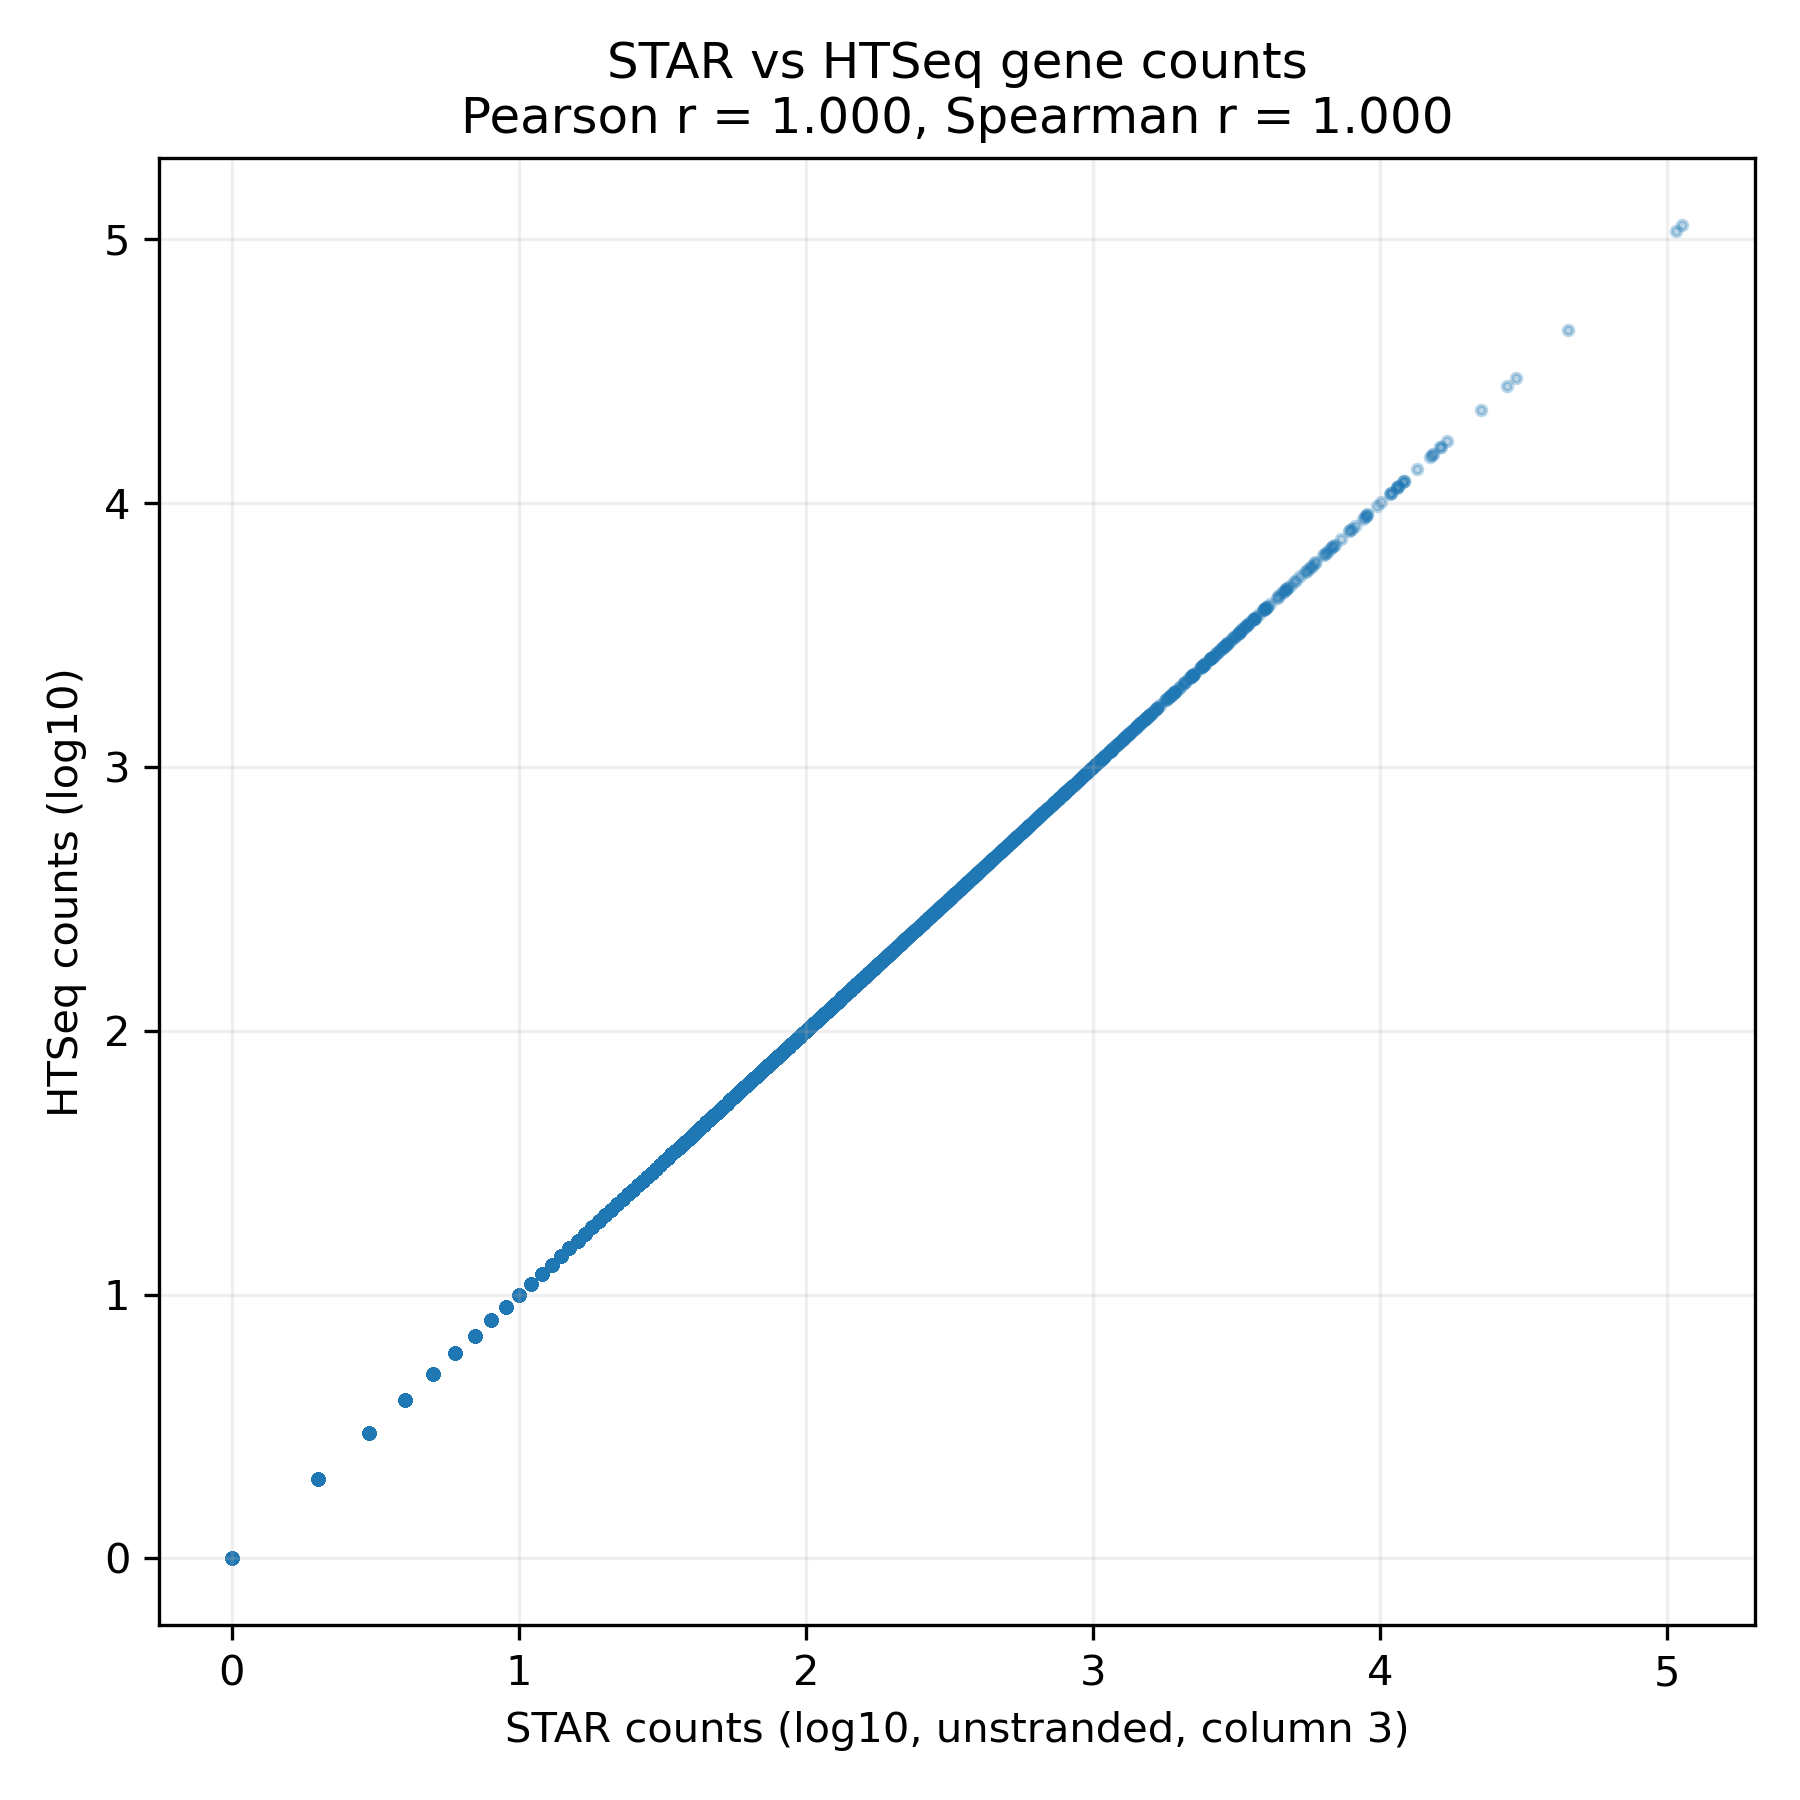

Сравнение каунтов STAR (колонка 3, unstranded) и HTSeq-count показало идеальную корреляцию (Pearson r = 1.000, Spearman r = 1.000).
Это означает, что оба метода дают идентичные оценки экспрессии для каждого гена при одинаковых параметрах аннотации и стрендности.


В реальных же RNA-seq экспериментах каунты STAR и HTSeq могут различаться из‑за разных правил учета ридов, обработки мультимапперов, настроек стрендности, различий в аннотации GTF и фильтрации неоднозначных выравниваний.

HTSeq-count использует более строгие критерии и обычно дает немного меньшие значения, тогда как STAR GeneCounts может включать больше ридов, особенно при нестрогих фильтрах мультимапперов.
Эти различия не являются ошибкой - они отражают особенности алгоритмов и должны учитываться при выборе метода для дифференциального анализа экспрессии.

Мне кажется, для дальнейшего DE-анализа (DESeq2/edgeR) предпочтительно использовать HTSeq-count, а не каунты STAR, так как HTSeq-count выполняет строгий подсчет ридов, пересекающих экзоны генов, исключает неоднозначныериды и строго следует аннотации GTF, что обеспечит корректность статистических моделей.

STAR GeneCounts же использует упрощенные внутренние правила учета ридов, может включать интронные и неоднозначные выравнивания и предназначен скорее для быстрой оценки экспрессии, а не для DE-анализа.
